In [ ]:
from google.colab import files
uploaded = files.upload()

Saving tasksonbitrix24.xlsx to tasksonbitrix24.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("tasksonbitrix24.xlsx")
print(df['Status'].value_counts())

Status
Completed      236
Pending         39
In Progress      4
Name: count, dtype: int64


In [ ]:
import pandas as pd

df = pd.read_excel('tasksonbitrix24.xlsx')
print(df.shape)
print(df.columns.tolist())

(279, 36)
['ID', 'Task', 'Description', 'Active', 'Deadline', 'Created by', 'Assignee', 'Participants', 'Observers', 'Status', 'Project', 'Created on', 'Start date', 'Modified on', 'Completed on', 'Planned duration', 'Track time spent', 'Rating', 'Assignee can change deadline', 'Time spent', 'Tags', 'Lead', 'Contact', 'Company', 'Deal', 'CRM', 'Parent task ID', 'Parent task name', 'Planned start date', 'Due date', 'Flow', 'Priority', 'Severity', 'Environment', 'Type', 'Platform']


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'tasks.xlsx', 'sample_data']


In [ ]:
print(df['Status'].value_counts())

Status
Completed      236
Pending         39
In Progress      4
Name: count, dtype: int64


In [ ]:
# Parse date columns
date_cols = ['Created on', 'Deadline', 'Completed on', 'Start date', 'Modified on']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Strip whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', pd.NA)

print("✅ Cleaning done!")
print(df.dtypes[date_cols])

✅ Cleaning done!
Created on      datetime64[ns]
Deadline        datetime64[ns]
Completed on    datetime64[ns]
Start date      datetime64[ns]
Modified on     datetime64[ns]
dtype: object


/tmp/ipykernel_11727/4287034741.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [ ]:
# Define testers (creators of bugs)
testers = ['Yara Mahmoud', 'Muhammed Talaat']

# Filter tasks created by testers
df_bugs = df[df['Created by'].isin(testers)].copy()

# Print results
print(f"✅ Total Bugs (created by testers): {len(df_bugs)}")

print("\nBugs per Creator:")
print(df_bugs['Created by'].value_counts())

# Show sample
df_bugs.head()

✅ Total Bugs (created by testers): 84

Bugs per Creator:
Created by
Muhammed Talaat    49
Yara Mahmoud       35
Name: count, dtype: int64


,ID,Task,Description,Active,Deadline,Created by,Assignee,Participants,Observers,Status,...,Parent task name,Planned start date,Due date,Flow,Priority,Severity,Environment,Type,Platform,Task Category
0,43816,Team Management Roles,Description : when creat a new role for Team M...,02/25/2026 09:59:05 am,NaT,Yara Mahmoud,Anwar Abdelmaksoud,NaN,<NA>,Completed,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
1,43826,change passwored for school,description : when change Password for merchan...,02/25/2026 09:59:13 am,NaT,Yara Mahmoud,Anwar Abdelmaksoud,NaN,<NA>,Completed,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
8,45332,Validation error after login : Failed to get o...,<NA>,02/23/2026 01:07:08 pm,NaT,Muhammed Talaat,Mohamed Salah,NaN,<NA>,Completed,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
48,45694,"Phone number with country code ""966"" it a diff...",<NA>,2026-01-03 12:01:38,NaT,Muhammed Talaat,Ahmad Maghrapy,NaN,<NA>,Completed,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
49,45702,"We Need to delete api ""delete"" and change this...",<NA>,2026-11-03 10:54:02,NaT,Muhammed Talaat,Ahmad Maghrapy,NaN,<NA>,Completed,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other


In [ ]:
# Define regular task creator
regular_user = 'Ahmed Abdelfattah'

# Filter tasks created by Ahmed
df_regular = df[df['Created by'] == regular_user].copy()

# Print results
print(f"✅ Total Regular Tasks: {len(df_regular)}")

print("\nTasks created by Ahmed:")
print(df_regular['Created by'].value_counts())

# Show sample
df_regular.head()

✅ Total Regular Tasks: 194

Tasks created by Ahmed:
Created by
Ahmed Abdelfattah    194
Name: count, dtype: int64


,ID,Task,Description,Active,Deadline,Created by,Assignee,Participants,Observers,Status,...,Parent task name,Planned start date,Due date,Flow,Priority,Severity,Environment,Type,Platform,Task Category
2,44756,[Chat Module - Supplier Dashboard] Implement D...,Add logic to handle and display long text mess...,02/16/2026 07:02:12 pm,NaT,Ahmed Abdelfattah,Anwar Abdelmaksoud,NaN,<NA>,Completed,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
3,44758,[Chat Module] Implement Dynamic Text Truncatio...,Add logic to handle and display long text mess...,02/16/2026 07:02:07 pm,NaT,Ahmed Abdelfattah,Anwar Abdelmaksoud,NaN,<NA>,Completed,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
4,44760,[Chat Module] Setup socket client to start con...,Setup socket client service to establish/relea...,02/16/2026 07:02:02 pm,NaT,Ahmed Abdelfattah,Anwar Abdelmaksoud,NaN,<NA>,Completed,...,[Chat Module] Integration with Socket.io :-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
5,44762,[Chat Module] Implement feature to display ima...,Implement a feature to display images in a lar...,02/16/2026 07:01:51 pm,NaT,Ahmed Abdelfattah,Anwar Abdelmaksoud,NaN,<NA>,Completed,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
6,44764,[Chat Module] Implement feature to display ima...,Implement a feature to display images in a lar...,02/16/2026 07:01:44 pm,NaT,Ahmed Abdelfattah,Anwar Abdelmaksoud,NaN,<NA>,Completed,...,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other


In [ ]:
testers = ['Yara Mahmoud', 'Muhammed Talaat']
regular_user = 'Ahmed Abdelfattah'
frontend_team = ['Anwar Abdelmaksoud', 'ammar elkhouly', 'Omar Adly']
backend_team = ['Mohamed Salah', 'Mahmoud Abdelhamid', 'Ahmad Maghrapy']

def categorize_task(row):
    if row['Created by'] in testers:
        return 'Bug'
    elif row['Created by'] == regular_user:
        return 'Regular Task'
    elif row['Assignee'] in frontend_team:
        return 'Frontend Task'
    elif row['Assignee'] in backend_team:
        return 'Backend Task'
    else:
        return 'Other'

df['Task Category'] = df.apply(categorize_task, axis=1)

print(df['Task Category'].value_counts())

Task Category
Regular Task    194
Bug              84
Other             1
Name: count, dtype: int64


In [ ]:
testers = ['Yara Mahmoud', 'Muhammed Talaat']
regular_user = 'Ahmed Abdelfattah'
frontend_team = ['Anwar Abdelmaksoud', 'ammar elkhouly', 'Omar Adly']
backend_team = ['Mohamed Salah', 'Mahmoud Abdelhamid', 'Ahmad Maghrapy']

def categorize_task(row):
    if row['Created by'] in testers:
        return 'Bug'
    elif row['Created by'] == regular_user:
        return 'Regular Task'
    elif row['Assignee'] in frontend_team:
        return 'Frontend Task'
    elif row['Assignee'] in backend_team:
        return 'Backend Task'
    else:
        return 'Other'

df['Task Category'] = df.apply(categorize_task, axis=1)

In [ ]:
df['Completion Time (days)'] = (
    df['Completed on'] - df['Created on']
).dt.days

In [ ]:
df['Is Late'] = df['Completed on'] > df['Deadline']

In [ ]:
df['Is Completed'] = df['Status'].str.lower().str.contains('complete', na=False)

In [ ]:
total_tasks = len(df)
completed_tasks = df['Is Completed'].sum()
completion_rate = completed_tasks / total_tasks * 100

print(f"Total Tasks: {total_tasks}")
print(f"Completed Tasks: {completed_tasks}")
print(f"Completion Rate: {completion_rate:.2f}%")

Total Tasks: 279
Completed Tasks: 236
Completion Rate: 84.59%


In [ ]:
bugs = df[df['Task Category'] == 'Bug']

print("Total Bugs:", len(bugs))
print("Bugs per Status:\n", bugs['Status'].value_counts())

Total Bugs: 84
Bugs per Status:
 Status
Completed      58
Pending        23
In Progress     3
Name: count, dtype: int64


In [ ]:
print(df.groupby('Task Category')['ID'].count())

Task Category
Bug              84
Other             1
Regular Task    194
Name: ID, dtype: int64


In [ ]:
print(df.groupby('Task Category')['Completion Time (days)'].mean())

Task Category
Bug             17.947368
Other                 NaN
Regular Task    95.149068
Name: Completion Time (days), dtype: float64


In [ ]:
late_tasks = df[df['Is Late'] == True]

print("Late Tasks:", len(late_tasks))
print(late_tasks['Task Category'].value_counts())

Late Tasks: 55
Task Category
Regular Task    52
Bug              3
Name: count, dtype: int64


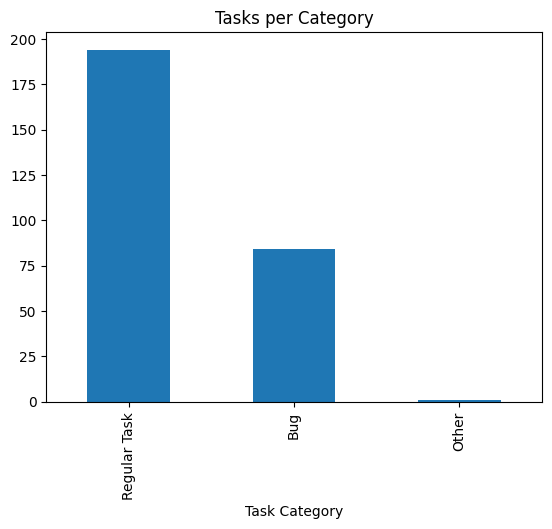

In [ ]:
import matplotlib.pyplot as plt

df['Task Category'].value_counts().plot(kind='bar')
plt.title("Tasks per Category")
plt.show()

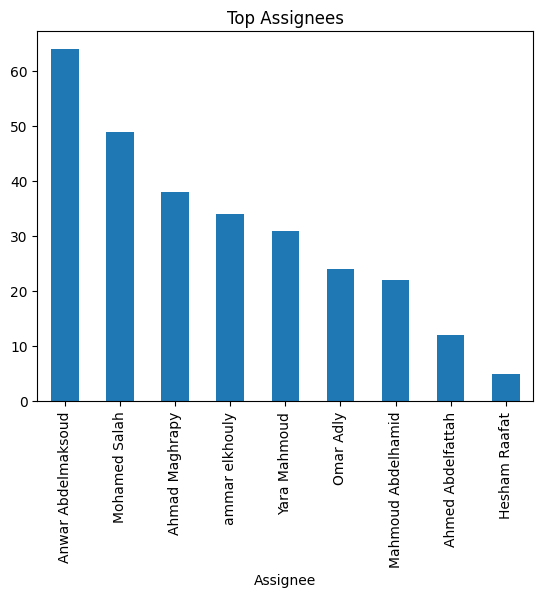

In [ ]:
df['Assignee'].value_counts().head(10).plot(kind='bar')
plt.title("Top Assignees")
plt.show()

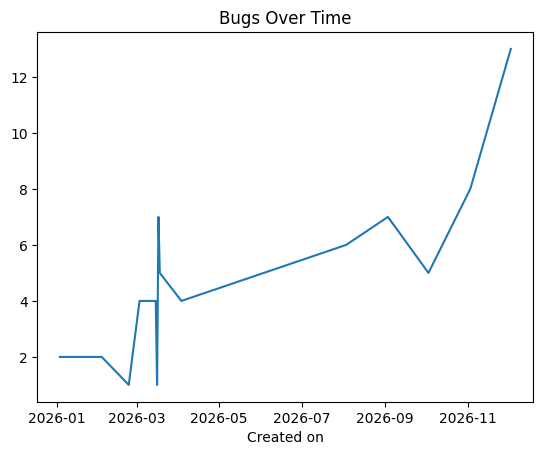

In [ ]:
bugs.groupby(df['Created on'].dt.date).size().plot()
plt.title("Bugs Over Time")
plt.show()

In [ ]:
df.to_csv("tasks_cleaned.csv", index=False)

In [ ]:
testers = ['Yara Mahmoud', 'Muhammed Talaat']

df['Is Bug'] = df['Created by'].isin(testers)

In [ ]:
assignee_summary = df.groupby('Assignee').agg(
    Total_Tasks=('ID', 'count'),
    Bugs=('Is Bug', 'sum')
)

# نحسب باقي التاسكات
assignee_summary['Non_Bug_Tasks'] = (
    assignee_summary['Total_Tasks'] - assignee_summary['Bugs']
)

assignee_summary = assignee_summary.sort_values(by='Total_Tasks', ascending=False)

assignee_summary

,Total_Tasks,Bugs,Non_Bug_Tasks
Assignee,,,
Anwar Abdelmaksoud,64,22,42
Mohamed Salah,49,15,34
Ahmad Maghrapy,38,17,21
ammar elkhouly,34,14,20
Yara Mahmoud,31,0,31
Omar Adly,24,11,13
Mahmoud Abdelhamid,22,3,19
Ahmed Abdelfattah,12,2,10
Hesham Raafat,5,0,5


In [ ]:
assignee_summary['Bug %'] = (
    assignee_summary['Bugs'] / assignee_summary['Total_Tasks'] * 100
)

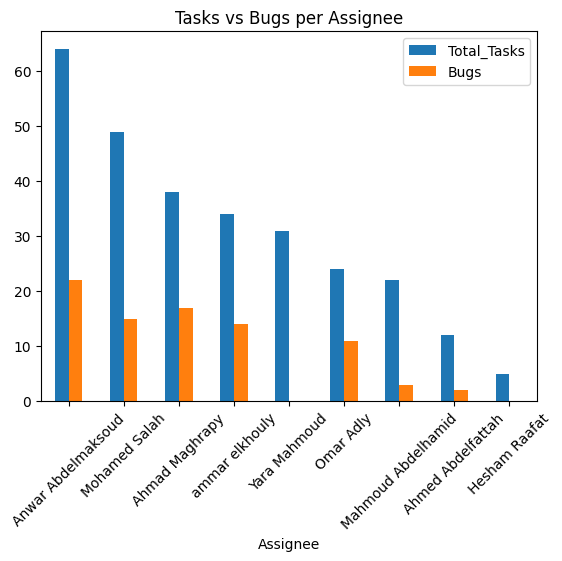

In [ ]:
assignee_summary[['Total_Tasks', 'Bugs']].plot(kind='bar')
plt.title("Tasks vs Bugs per Assignee")
plt.xticks(rotation=45)
plt.show()

In [ ]:
pivot = pd.pivot_table(
    df,
    index='Assignee',
    columns='Task Category',
    values='ID',
    aggfunc='count',
    fill_value=0
)

pivot

Task Category,Bug,Other,Regular Task
Assignee,,,
Ahmad Maghrapy,17,0,21
Ahmed Abdelfattah,2,0,10
Anwar Abdelmaksoud,22,0,42
Hesham Raafat,0,1,4
Mahmoud Abdelhamid,3,0,19
Mohamed Salah,15,0,34
Omar Adly,11,0,13
Yara Mahmoud,0,0,31
ammar elkhouly,14,0,20


In [ ]:
# تعريف الفرق و الـ testers
testers = ['Yara Mahmoud', 'Muhammed Talaat']
regular_user = 'Ahmed Abdelfattah'
frontend_team = ['Anwar Abdelmaksoud', 'ammar elkhouly', 'Omar Adly']
backend_team = ['Mohamed Salah', 'Mahmoud Abdelhamid', 'Ahmad Maghrapy']

# التصنيف
def categorize_task(row):
    if row['Created by'] in testers:
        return 'Bug'
    elif row['Created by'] == regular_user:
        return 'Regular Task'
    elif row['Assignee'] in frontend_team:
        return 'Frontend Task'
    elif row['Assignee'] in backend_team:
        return 'Backend Task'
    else:
        return 'Other'

df['Task Category'] = df.apply(categorize_task, axis=1)

# تحديد Bugs
df['Is Bug'] = df['Created by'].isin(testers)

# مدة التنفيذ بالايام
df['Completion Time (days)'] = (df['Completed on'] - df['Created on']).dt.days

# هل التاسك اتأخر؟
df['Is Late'] = df['Completed on'] > df['Deadline']

# Completed flag
df['Is Completed'] = df['Status'].str.lower().str.contains('complete', na=False)

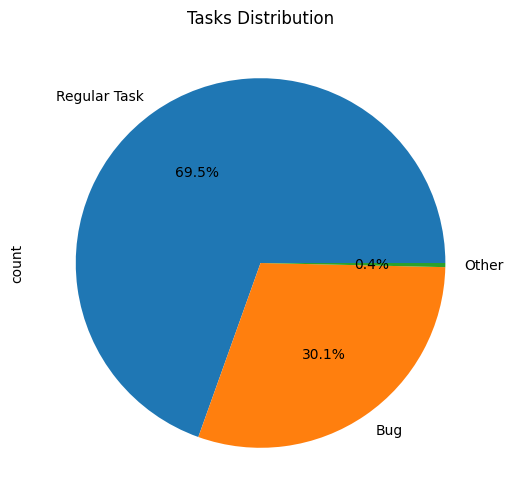

In [ ]:
df['Task Category'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), title='Tasks Distribution')
plt.show()

In [ ]:
completion_rate = df['Is Completed'].mean() * 100
print(f"✅ Completion Rate: {completion_rate:.2f}%")

✅ Completion Rate: 84.59%


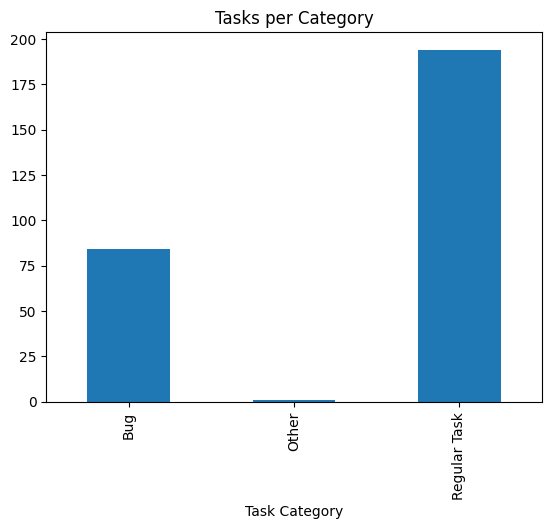

In [ ]:
df.groupby('Task Category')['ID'].count().plot(kind='bar', title='Tasks per Category')
plt.show()

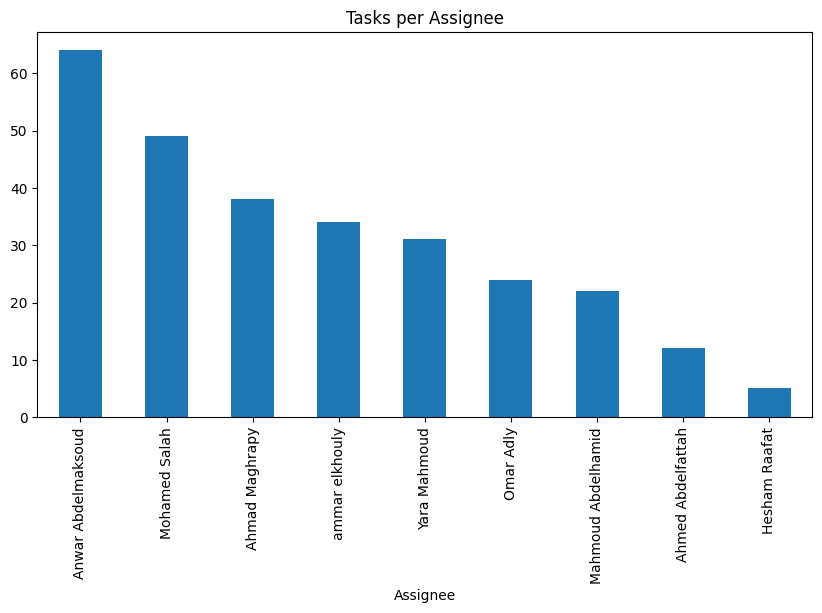

In [ ]:
df['Assignee'].value_counts().plot(kind='bar', figsize=(10,5), title='Tasks per Assignee')
plt.show()

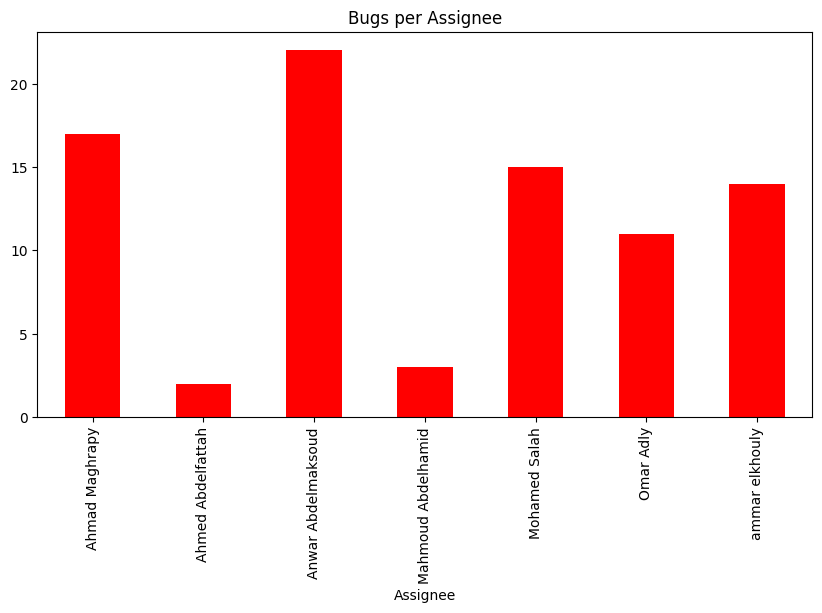

In [ ]:
df[df['Is Bug']].groupby('Assignee')['ID'].count().plot(kind='bar', color='red', figsize=(10,5), title='Bugs per Assignee')
plt.show()

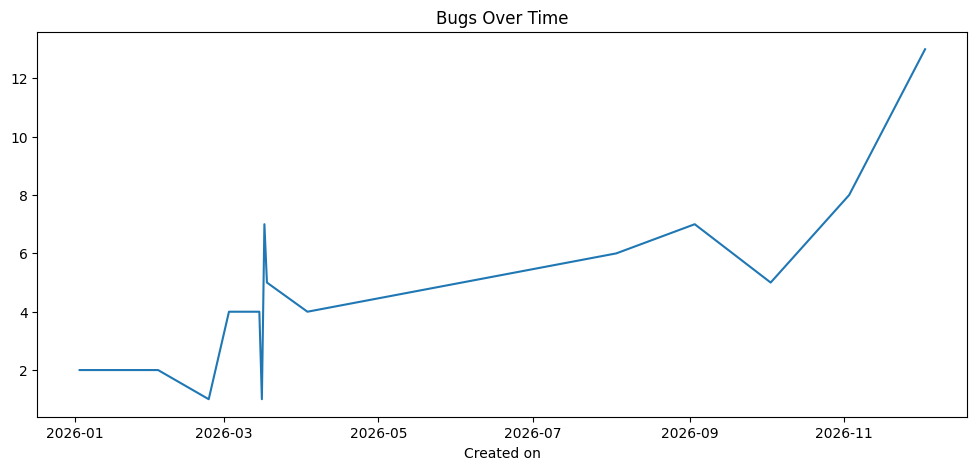

In [ ]:
df[df['Is Bug']].groupby(df['Created on'].dt.date)['ID'].count().plot(figsize=(12,5), title='Bugs Over Time')
plt.show()

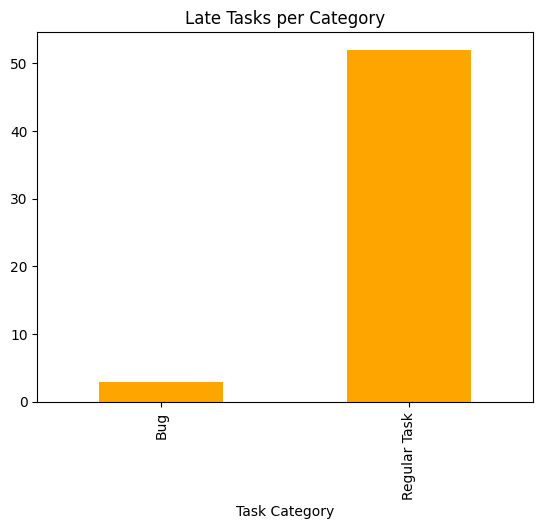

In [ ]:
df[df['Is Late']].groupby('Task Category')['ID'].count().plot(kind='bar', color='orange', title='Late Tasks per Category')
plt.show()

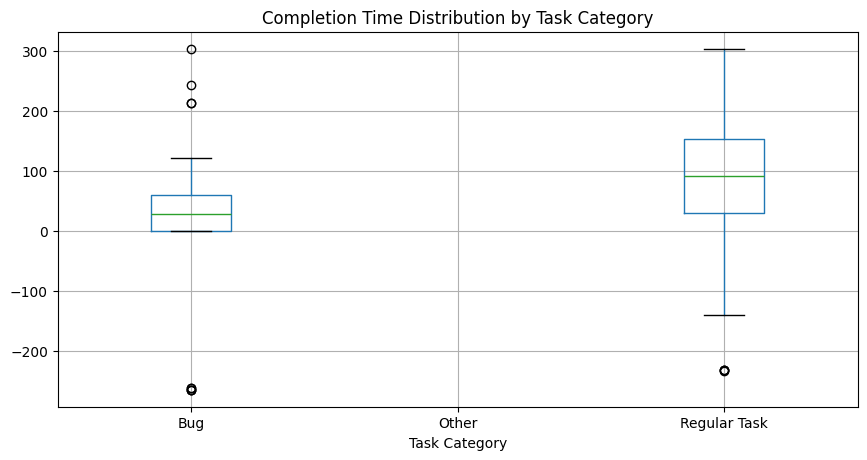

In [ ]:
df.boxplot(column='Completion Time (days)', by='Task Category', figsize=(10,5))
plt.title("Completion Time Distribution by Task Category")
plt.suptitle('')
plt.show()

In [ ]:
df.to_csv('tasks_dashboard.csv', index=False)

In [ ]:
df[['ID','Task','Assignee','Task Category','Status','Deadline','Completion Time (days)','Is Late']]

,ID,Task,Assignee,Task Category,Status,Deadline,Completion Time (days),Is Late
0,43816,Team Management Roles,Anwar Abdelmaksoud,Bug,Completed,NaT,29.0,False
1,43826,change passwored for school,Anwar Abdelmaksoud,Bug,Completed,NaT,29.0,False
2,44756,[Chat Module - Supplier Dashboard] Implement D...,Anwar Abdelmaksoud,Regular Task,Completed,NaT,NaN,False
3,44758,[Chat Module] Implement Dynamic Text Truncatio...,Anwar Abdelmaksoud,Regular Task,Completed,NaT,NaN,False
4,44760,[Chat Module] Setup socket client to start con...,Anwar Abdelmaksoud,Regular Task,Completed,NaT,NaN,False
...,...,...,...,...,...,...,...,...
274,46928,RFQ field in Add Product accepts only integers...,Mahmoud Abdelhamid,Bug,Completed,2026-03-25 19:00:00,NaN,False
275,46930,Port and Lead Time fields are not required whe...,Anwar Abdelmaksoud,Bug,Pending,2026-03-25 19:00:00,NaN,False
276,46944,Need to enhancement this screen,ammar elkhouly,Bug,Pending,NaT,NaN,False
277,46948,Incorrect text direction when switching to Ara...,ammar elkhouly,Bug,Pending,2026-03-25 19:00:00,NaN,False


In [ ]:
# احفظ DataFrame بعد التنظيف و التصنيف
df.to_csv("tasks_dashboard.csv", index=False)

In [ ]:
from google.colab import files

files.download("tasks_dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ── Setup ──
# نحدد أول تاسك اتفتح كبداية المشروع
project_start = df['Created on'].min().normalize()
project_end   = pd.Timestamp('2026-03-24')
today         = pd.Timestamp('2026-03-24')

# ── نعمل سبرينتات كل أسبوعين ──
sprints = []
current = project_start
while current <= project_end:
    sprint_end = current + pd.Timedelta(days=13)
    sprints.append({'start': current, 'end': min(sprint_end, project_end)})
    current = sprint_end + pd.Timedelta(days=1)

print(f"Total sprints (2-week periods): {len(sprints)}")
for i, s in enumerate(sprints):
    print(f"  Sprint {i+1}: {s['start'].date()} → {s['end'].date()}")

Total sprints (2-week periods): 6
  Sprint 1: 2026-01-03 → 2026-01-16
  Sprint 2: 2026-01-17 → 2026-01-30
  Sprint 3: 2026-01-31 → 2026-02-13
  Sprint 4: 2026-02-14 → 2026-02-27
  Sprint 5: 2026-02-28 → 2026-03-13
  Sprint 6: 2026-03-14 → 2026-03-24


In [ ]:
# ── حساب Burndown و Velocity لكل سبرينت ──
burndown_data = []

for i, sprint in enumerate(sprints):
    s_start = sprint['start']
    s_end   = sprint['end']

    # التاسكات اللي كانت مفتوحة في بداية السبرينت
    # (اتعملت قبل أو أثناء السبرينت ولسه مش مقفولة)
    open_at_start = df[df['Created on'] <= s_start]

    # اللي اتقفلت قبل بداية السبرينت
    closed_before = df[
        (df['Completed on'].notna()) &
        (df['Completed on'] < s_start)
    ]

    remaining_start = len(open_at_start) - len(closed_before)

    # اللي اتقفلت خلال السبرينت ده
    closed_in_sprint = df[
        (df['Completed on'] >= s_start) &
        (df['Completed on'] <= s_end)
    ]
    velocity = len(closed_in_sprint)

    # الـ remaining في نهاية السبرينت
    remaining_end = remaining_start - velocity

    burndown_data.append({
        'Sprint':           f"S{i+1}\n{s_start.strftime('%d %b')}",
        'Start':            s_start,
        'Remaining Start':  remaining_start,
        'Remaining End':    remaining_end,
        'Velocity':         velocity,
    })

bd = pd.DataFrame(burndown_data)
print(bd[['Sprint', 'Remaining Start', 'Velocity', 'Remaining End']].to_string(index=False))

    Sprint  Remaining Start  Velocity  Remaining End
S1\n03 Jan                0         6             -6
S2\n17 Jan               22         0             22
S3\n31 Jan               24        12             12
S4\n14 Feb               31         4             27
S5\n28 Feb               43         7             36
S6\n14 Mar               48        12             36


In [ ]:
print(f"Tasks with Completed on filled: {df['Completed on'].notna().sum()}")
print(f"\nStatus values: {df['Status'].unique()}")

Tasks with Completed on filled: 200

Status values: ['Completed' 'Pending' 'In Progress']


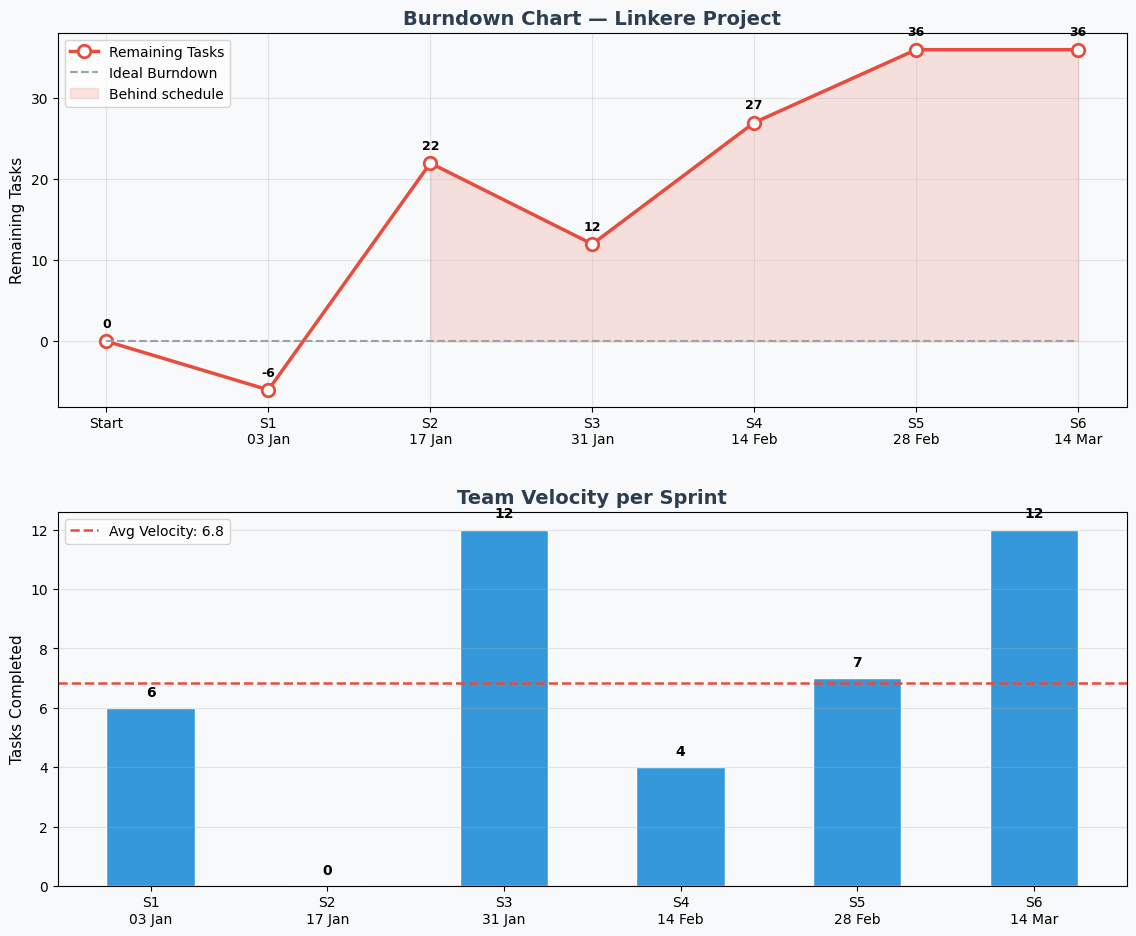

✅ Chart saved!


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.patch.set_facecolor('#f8f9fa')

# ── Burndown Chart ──
ax1.set_facecolor('#f8f9fa')

remaining_points = [bd.iloc[0]['Remaining Start']] + bd['Remaining End'].tolist()
sprint_labels    = ['Start'] + bd['Sprint'].tolist()

ax1.plot(sprint_labels, remaining_points,
         marker='o', linewidth=2.5, color='#e74c3c',
         markerfacecolor='white', markeredgewidth=2, markersize=9,
         label='Remaining Tasks')

# Ideal burndown line
total_tasks = remaining_points[0]
ideal = np.linspace(total_tasks, 0, len(sprint_labels))
ax1.plot(sprint_labels, ideal,
         linestyle='--', color='#95a5a6', linewidth=1.5, label='Ideal Burndown')

# Fill under curve
ax1.fill_between(sprint_labels, remaining_points, ideal,
                  where=[r > i for r, i in zip(remaining_points, ideal)],
                  alpha=0.15, color='#e74c3c', label='Behind schedule')

for i, val in enumerate(remaining_points):
    ax1.annotate(str(val), (sprint_labels[i], val),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, fontweight='bold')

ax1.set_title('Burndown Chart — Linkere Project', fontsize=14, fontweight='bold', color='#2c3e50')
ax1.set_ylabel('Remaining Tasks', fontsize=11)
ax1.legend()
ax1.grid(alpha=0.3)

# ── Velocity Chart ──
ax2.set_facecolor('#f8f9fa')

sprint_names = bd['Sprint'].tolist()
velocities   = bd['Velocity'].tolist()
avg_velocity = np.mean(velocities)

bars = ax2.bar(sprint_names, velocities,
               color='#3498db', edgecolor='white', width=0.5)

# Average line
ax2.axhline(y=avg_velocity, color='#e74c3c', linestyle='--',
            linewidth=1.8, label=f'Avg Velocity: {avg_velocity:.1f}')

for bar, val in zip(bars, velocities):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('Team Velocity per Sprint', fontsize=14, fontweight='bold', color='#2c3e50')
ax2.set_ylabel('Tasks Completed', fontsize=11)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(pad=3)
plt.savefig('burndown_velocity.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

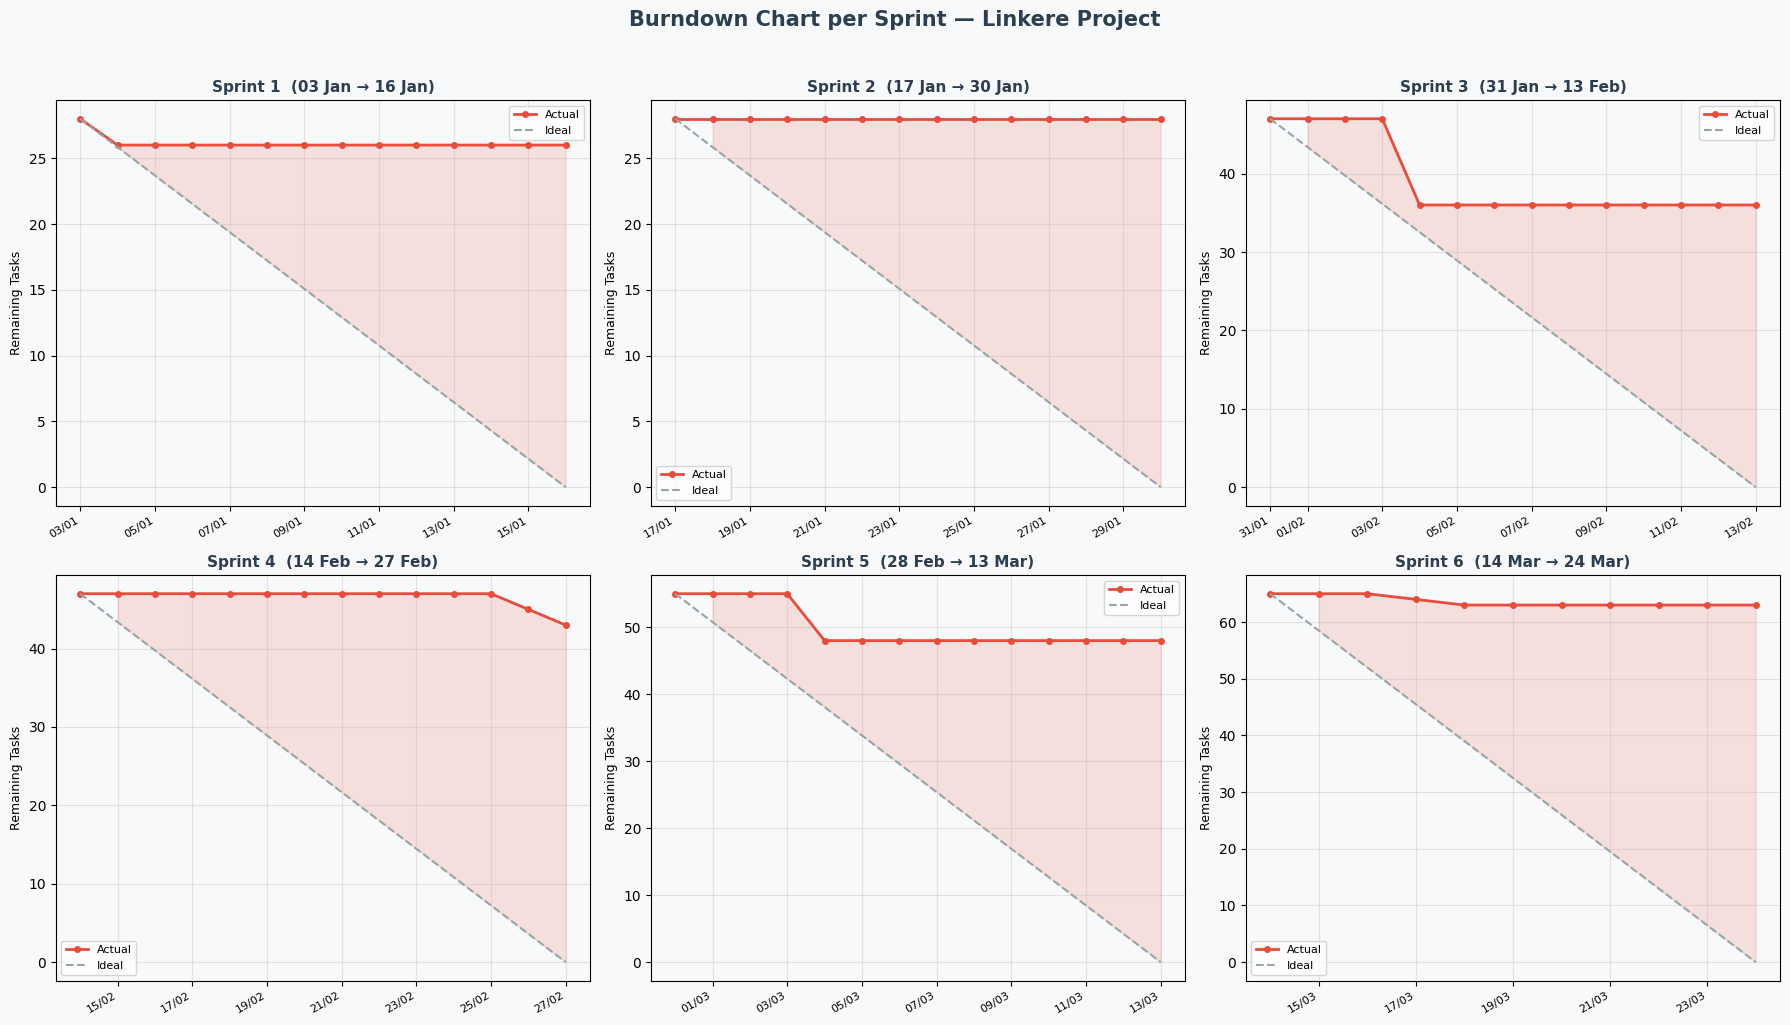

✅ Done!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f8f9fa')
axes = axes.flatten()

for i, sprint in enumerate(sprints):
    ax = axes[i]
    ax.set_facecolor('#f8f9fa')

    s_start = sprint['start']
    s_end   = sprint['end']

    # التاسكات اللي كانت شغالة في السبرينت ده
    active = df[df['Created on'] <= s_end].copy()

    # نعمل daily dates للسبرينت
    days = pd.date_range(start=s_start, end=s_end, freq='D')

    remaining_per_day = []
    for day in days:
        # التاسكات اللي لسه مفتوحة في اليوم ده
        remaining = len(active[
            (active['Completed on'].isna()) |
            (active['Completed on'] > day)
        ])
        remaining_per_day.append(remaining)

    # Ideal line
    ideal = np.linspace(remaining_per_day[0], 0, len(days))

    ax.plot(days, remaining_per_day,
            marker='o', markersize=4, linewidth=2,
            color='#e74c3c', label='Actual')
    ax.plot(days, ideal,
            linestyle='--', linewidth=1.5,
            color='#95a5a6', label='Ideal')
    ax.fill_between(days, remaining_per_day, ideal,
                    where=[r > id for r, id in zip(remaining_per_day, ideal)],
                    alpha=0.15, color='#e74c3c')

    ax.set_title(f'Sprint {i+1}  ({s_start.strftime("%d %b")} → {s_end.strftime("%d %b")})',
                 fontsize=11, fontweight='bold', color='#2c3e50')
    ax.set_ylabel('Remaining Tasks', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Burndown Chart per Sprint — Linkere Project',
             fontsize=15, fontweight='bold', color='#2c3e50', y=1.02)
plt.tight_layout()
plt.savefig('burndown_per_sprint.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Done!")

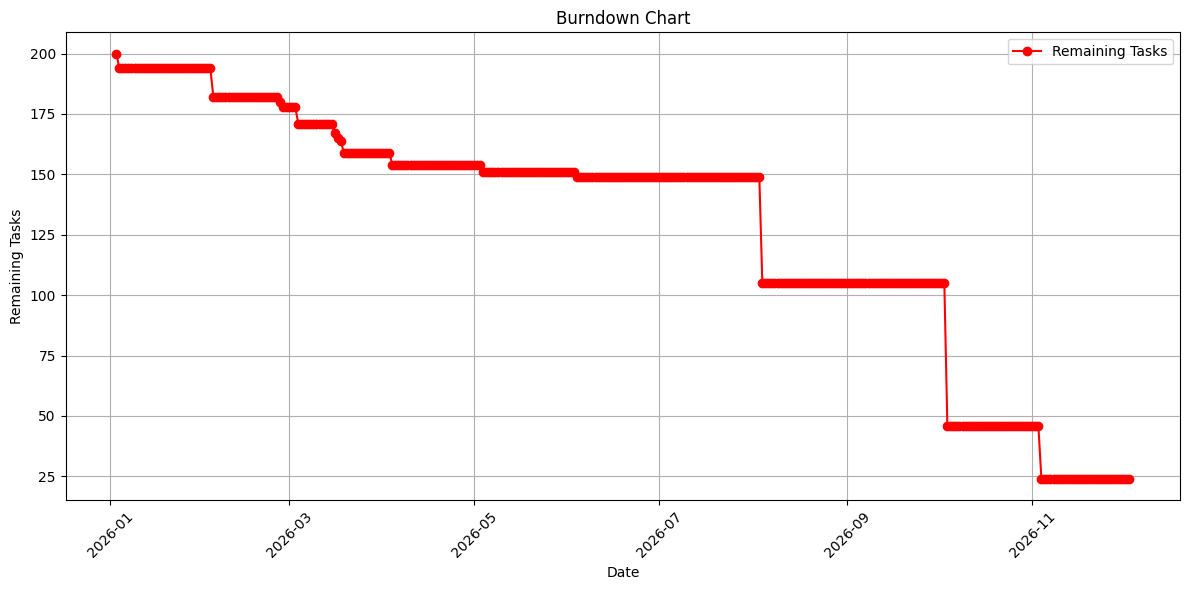

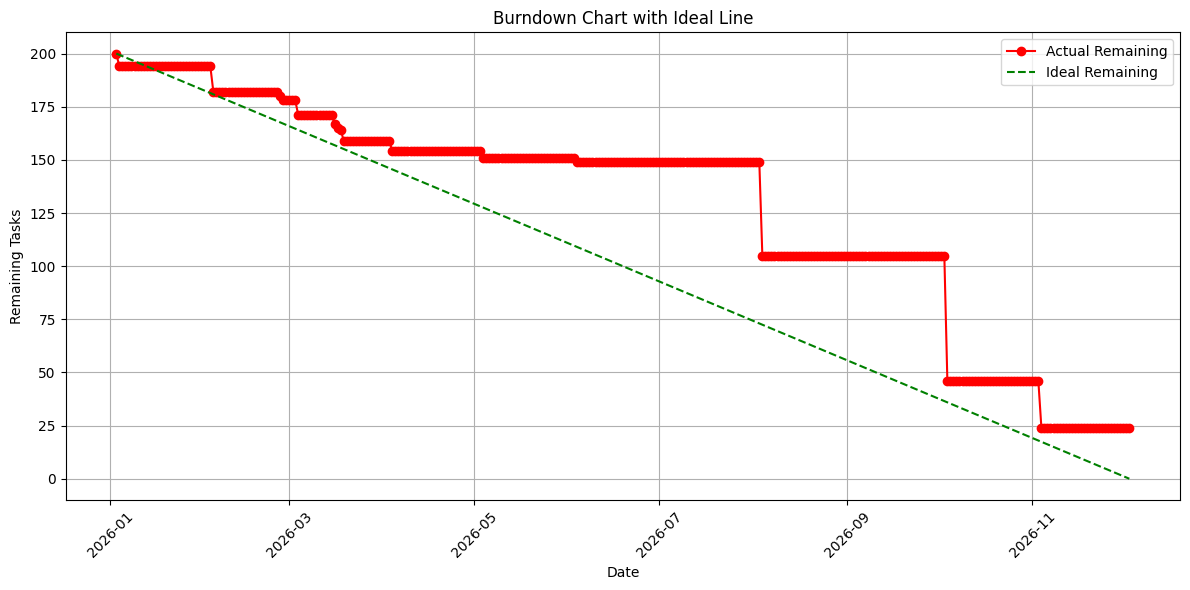

In [ ]:
# خط مثالي - linear decrease
ideal_remaining = [remaining_tasks[0] - i*(remaining_tasks[0]/(len(all_days)-1)) for i in range(len(all_days))]

plt.figure(figsize=(12,6))
plt.plot(burndown_df['Date'], remaining_tasks, marker='o', color='red', label='Actual Remaining')
plt.plot(burndown_df['Date'], ideal_remaining, linestyle='--', color='green', label='Ideal Remaining')
plt.title('Burndown Chart with Ideal Line')
plt.xlabel('Date')
plt.ylabel('Remaining Tasks')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

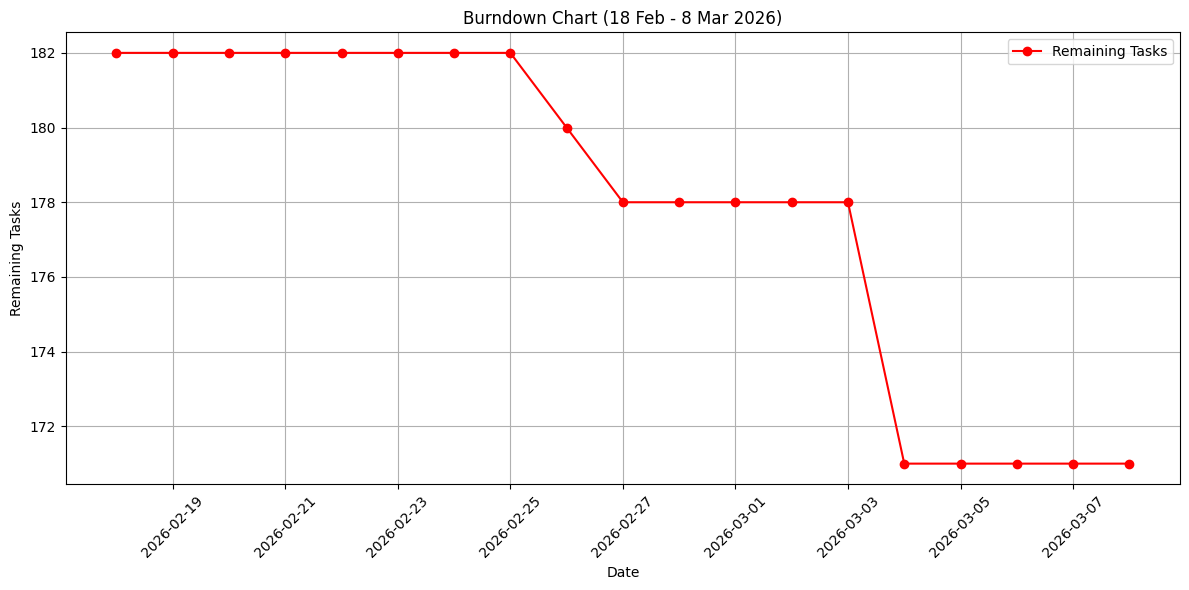

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# تأكد أن الأعمدة datetime
df['Created on'] = pd.to_datetime(df['Created on'])
df['Completed on'] = pd.to_datetime(df['Completed on'])

# تحديد الفترة المطلوبة
start_date = pd.Timestamp('2026-02-18')
end_date   = pd.Timestamp('2026-03-08')

# أنشئ كل الأيام بين البداية والنهاية
all_days = pd.date_range(start=start_date, end=end_date, freq='D')

# احسب المهام المتبقية لكل يوم
remaining_tasks = []

for day in all_days:
    remaining = df[df['Completed on'] > day].shape[0]
    remaining_tasks.append(remaining)

# DataFrame جاهز للـ Burndown
burndown_df = pd.DataFrame({
    'Date': all_days,
    'Remaining Tasks': remaining_tasks
})

# رسم Burndown Chart
plt.figure(figsize=(12,6))
plt.plot(burndown_df['Date'], burndown_df['Remaining Tasks'], marker='o', color='red', label='Remaining Tasks')
plt.title('Burndown Chart (18 Feb - 8 Mar 2026)')
plt.xlabel('Date')
plt.ylabel('Remaining Tasks')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
start_date = pd.Timestamp('2026-02-01')
end_date   = pd.Timestamp('2026-03-24 23:59:59')

df_filtered = df[
    (df['Created on'] >= start_date) &
    (df['Created on'] <= end_date)
].copy()

print(f"✅ Total tasks in range: {len(df_filtered)}")
print("\nTasks per Assignee:")
print(df_filtered['Assignee'].value_counts())

✅ Total tasks in range: 64

Tasks per Assignee:
Assignee
Mohamed Salah         22
Anwar Abdelmaksoud    17
Omar Adly              8
Ahmad Maghrapy         5
Ahmed Abdelfattah      5
ammar elkhouly         4
Mahmoud Abdelhamid     3
Name: count, dtype: int64


In [ ]:
def categorise(assignee):
    if assignee == 'Yara Mahmoud':
        return 'Bug'
    elif assignee == 'Ahmed Abdelfattah':
        return 'Regular Task'
    else:
        return 'General'

df_filtered['Task Category'] = df_filtered['Assignee'].apply(categorise)

print(df_filtered['Task Category'].value_counts())

Task Category
General         59
Regular Task     5
Name: count, dtype: int64


In [ ]:
def categorise(created_by):
    if created_by in ['Yara Mahmoud', 'Muhammed Talaat']:
        return 'Bug'
    else:
        return 'Regular Task'

df_filtered['Task Category'] = df_filtered['Created by'].apply(categorise)

print(df_filtered['Task Category'].value_counts())
print("\n--- Sample ---")
print(df_filtered[['Task', 'Created by', 'Assignee', 'Task Category']].to_string())

Task Category
Regular Task    40
Bug             24
Name: count, dtype: int64

--- Sample ---
                                                                                                                Task         Created by            Assignee Task Category
8                                                      Validation error after login : Failed to get or create wallet    Muhammed Talaat       Mohamed Salah           Bug
9                                                          [Linker Project] Review the Code structure and ERD Design  Ahmed Abdelfattah      Ahmad Maghrapy  Regular Task
10                                                [Admin Chat] Return the supplier and merchant image in chat Module  Ahmed Abdelfattah       Mohamed Salah  Regular Task
11                            [Admin Module] Create API for Add Supplier in Admin Dashboard and make it auto approve  Ahmed Abdelfattah       Mohamed Salah  Regular Task
12                   [Linker Responsive - Admin Module] 

In [ ]:
yara_tasks = df_filtered[df_filtered['Created by'] == 'Yara Mahmoud']

print(f"Total Yara's tasks: {len(yara_tasks)}")
print(yara_tasks[['Task', 'Assignee', 'Status', 'Created on', 'Deadline']].to_string())

Total Yara's tasks: 6
                                                                           Task            Assignee     Status          Created on            Deadline
249                      Updating profile email incorrectly updates School Info           Omar Adly  Completed 2026-03-15 10:49:58                 NaT
250        Incorrect OTP validation during password reset in Supplier Dashboard       Mohamed Salah  Completed 2026-03-15 11:13:47                 NaT
256  Capacity field is required in Add Product but not required in Edit Product  Anwar Abdelmaksoud  Completed 2026-03-16 11:31:14                 NaT
262         Unable to create RFQ Request – "Failed to create RFQ Request" error       Mohamed Salah    Pending 2026-03-17 11:20:46                 NaT
263                   Product page shows "Coming Soon" when opened in a new tab      ammar elkhouly  Completed 2026-03-17 11:40:17 2026-03-18 19:00:00
264  Unable to decrease product quantity in cart after adding from produ

In [ ]:
print(df['Created by'].unique())

['Yara Mahmoud' 'Ahmed Abdelfattah' 'Muhammed Talaat' 'Hesham Raafat']


In [ ]:
yara_tasks = df[df['Created by'] == 'Yara Mahmoud']

print(f"Total Yara's tasks: {len(yara_tasks)}")
print(yara_tasks[['Task', 'Assignee', 'Status', 'Created on', 'Deadline']].to_string())

Total Yara's tasks: 30
                                                                                                                                                        Task            Assignee     Status          Created on            Deadline
0                                                                                                                                      Team Management Roles  Anwar Abdelmaksoud  Completed 2026-01-26 11:26:05                 NaT
1                                                                                                                                change passwored for school  Anwar Abdelmaksoud  Completed 2026-01-26 11:58:50                 NaT
190                                                                 Application link fields become mandatory when cleared and prevent saving phone and email      ammar elkhouly  Completed 2026-09-03 10:29:24 2026-03-16 19:00:00
192                                                              

In [ ]:
tatah_tasks = df[df['Created by'] == 'Ahmed Abdelfattah']

print(f"Total Abdelfatah's tasks: {len(tatah_tasks)}")
print(tatah_tasks[['Task', 'Assignee', 'Status', 'Created on', 'Deadline']].to_string())

Total Abdelfatah's tasks: 194
                                                                                                                Task            Assignee       Status          Created on            Deadline
2                             [Chat Module - Supplier Dashboard] Implement Dynamic Text Truncation for Chat Messages  Anwar Abdelmaksoud    Completed 2026-11-02 10:52:24                 NaT
3                                                  [Chat Module] Implement Dynamic Text Truncation for Chat Messages  Anwar Abdelmaksoud    Completed 2026-11-02 10:53:00                 NaT
4                                            [Chat Module] Setup socket client to start connection and chat services  Anwar Abdelmaksoud    Completed 2026-11-02 10:53:42                 NaT
5                                                    [Chat Module] Implement feature to display image in larger view  Anwar Abdelmaksoud    Completed 2026-11-02 10:53:59                 NaT
6                   

In [ ]:
Talaat_tasks = df[df['Created by'] == 'Muhammed Talaat']

print(f"Total Talaat's tasks: {len(tatah_tasks)}")
print(Talaat_tasks[['Task', 'Assignee', 'Status', 'Created on', 'Deadline']].to_string())

Total Talaat's tasks: 194
                                                                                            Task            Assignee       Status          Created on Deadline
8                                  Validation error after login : Failed to get or create wallet       Mohamed Salah    Completed 2026-02-23 11:04:09      NaT
48                          Phone number with country code "966" it a different number with "05"      Ahmad Maghrapy    Completed 2026-01-03 11:30:02      NaT
49                    We Need to delete api "delete" and change this to toggle Active /in-active      Ahmad Maghrapy    Completed 2026-01-03 13:33:35      NaT
54                           wrong in change password in admin , and not login with new password       Mohamed Salah    Completed 2026-02-03 10:33:58      NaT
72                                                                     500 Internal Server Error   Ahmed Abdelfattah      Pending 2026-02-03 14:14:25      NaT
79                  

In [ ]:
print(df['Status'].value_counts())

Status
Completed      228
Pending         41
In Progress      4
Name: count, dtype: int64
